# AAI6640 2026 Spring Assignment 5

## Section One: Conceptual Understanding

## <div class="alert alert-info">[GRADED TASK 1.1] Transformer</div>

Explain the attention mechanism used in the original Transformer paper.

## Your answer here

Using Scaled Dot-product attention, it was the core attention mechanism that took each token as a input sequence which is broken down into 3 vectors:

Query (Q)
Key (K)
Value (V)

These vector are learned through linear transformation and can be computed as: 

W^Q
W^K
W^V 

with a forumla of: Attention (W,K,V) = softmax(QK^T / sqrt(d_k)) * V

The Dot Product: QK^T
- the goal of this is to produce a score for every token pair. Measures the significance of each token to the next

softmax is a type of type of activation function that is used to turn raw scores into useable weights and normalize the values to a sum of 1. Without it would be hard to weigh the importance of the scores.

furthermore, sqrt(d_k) is used to divide scores by the square root of the key (K) dimension. This is critial in preventing softmax from saturating into near-zero gradients

The Transformer is further extended into the Mult-head attention forumla, which is use to capture various relationships simltaniouesly. 

MultiHead (Q,K,V) = Concat(head_1,...,head_h) * W^O

the attention operations are then ran parallel with each projection then concatenated on the outputted results. 

allowing the Transformer to work in several subspacs at once, like one can capture syntatic relationships , another can capter semantic similarity. Can be represented as a self-attention for the encoder, masked self-attentention in the decoder and cross-attention a combination of both in the encodeer and decoder

## <div class="alert alert-info">[GRADED TASK 1.2] GAN</div>

Develop a clear understanding of different Generative Adversarial Network (GAN) architectures by comparing a simple GAN, DCGAN, and WGAN in terms of their conceptual foundations and architectural differences.

## Your answer here
Reference: 
"Generative Adversarial Nets" — Goodfellow, Pouget-Abadie, Mirza, Xu, Warde-Farley, Ozair, Courville, Bengio (2014)
https://arxiv.org/abs/1406.2661


All 3 models are composed of the same of the same foundational methodology:

(G) Generator - generates random fake data from random noise 

(D) Discriminator - distinguishes the real from the fake

This framework was proposed by Goodfellow(2014) and its goal was to understand the differences between architectures build and how they are measured

Simple GAN 
- Full connected MLP for both G and D 
- training objective minimax using BCELoss (Binary Cross Entropy Loss) for binary classification
- Sigmoid activation for probability (real (1) or fake (0))
- prone to model collapse when D results in overconfidence saturatoin and cause vanishing gradients
-produces a narrow range of outputs
- doesnt require normalization
- Training Ratio 1:1 of G to D updates
- Stability: poor 

DCGAN:
- BCELoss but uses DCN (Deep Convolutional Networks), replaces MLPs and transposed convolutions in G and strided convolutionas in D. 
- BCEWithLogitsLoss (raw outputs required)
- Uses Normalization: BatchNorm2d in both G & D
- LeakyReLU activation used in D to prevent dying gradients, allows a small non-zero gradient for negative values
- Sigmoid Activation
- Training Ratio 1:1
- Stability: Better, but can still fail

WGAN:
- Core functionality is to measure how far the generated distribution is from the real one and to address loss level
- No Sigmoid activation
- outputs are an unbounded score
- prone to vanishing gradients 
- BatchBorm on G only
- Training Ratio: 1:5 (G:Critic)
- Loss: Wasserstein + Gradient Penalty 
- Stability: Best 


---------------
The conceptual differences simple GAN and DCGAN train as binary classification while WGAN uses Wasserstein distance, measuring how far apart the real and generated distributions are from each other.

GAN/DCGAN retrieve and output of real/fake probability, and when D confidence is high it results in risk of vanishing gradients
WGAN measures which side of the boundaries the generated distribution is on. 

The use of Gradient Penalty enforces 1-Lipschitz constrant, yielding stable linear gradients during training 



# Section Two - Coding Practice

## <div class="alert alert-info">[GRADED TASK 2.1]</div>
Design, implement, and evaluate a simple Generative Adversarial Network (GAN) capable of generating realistic-looking images from the CIFAR-10 dataset.

Architecture (fully connected) for __Generator__ Design (G):
- Input: 100-dim noise vector
- Dense (128 units) + ReLU
- Dense (256 units) + ReLU
- Dense (512 units) + ReLU
- Dense (784 units) + Tanh
- Reshape → (28, 28)

Architecture for __Discriminator__ Design (D)
- Input: 784-dim flattened image
- Dense (512 units) + LeakyReLU
- Dense (256 units) + LeakyReLU
- Dense (1 unit) + Sigmoid



In [65]:
# ------ Imports and Device Setup ------
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("=" * 50)
print("All imports successful and device setup complete.")

Using device: cpu
All imports successful and device setup complete.


In [5]:
# ------ Hyperparameters ------
batch_size = 128        # images per training batch
learning_rate = 0.0002  # Adam standard learning rate for GANs
num_epochs = 100        # number of training iterations
z_dim = 100             # random noise vector size for generator (G) input

In [6]:
'''Loads the CIFAR-10 dataset, applies transformations, and creates data loaders for training and testing.
Uses Normalization to set the mean and std to 0.5 for each channel
- common practice for GANs to help stabilize training. 
- maps pixel values from [0, 1] (real images) to [-1, 1] (Tanh outputs), which is beneficial for the generator's output layer activation (tanh).

- the Discriminator (D) can learn to distinguish between real and generated images more effectively,
- the Generator (G) can produce images that are more realistic and diverse, leading to better results.

- Computed across 50,000 training images in the CIFAR-10 dataset
- 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
- Each image is 32x32 pixels with 3 color channels (RGB)

references:

- https://www.kaggle.com/code/ashishpatel26/cifar10-gan-pytorch
- https://www.kaggle.com/code/ashishpatel26/cifar10-

Datasets:
https://stackoverflow.com/questions/47432168/taking-subsets-of-a-pytorch-dataset
'''
# ------ Data Loading ------

def get_cifar10_dataloaders(batch_size):
    # Transform train and test datasets separately, we want the data augmentation to be applied on the training set only

    transform = transforms.Compose([
        transforms.ToTensor(), # converting the image to a tensor Pytorch
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])     # Normalization 
    ])

    # get dataset using torchvision
    dataset = torchvision.datasets.CIFAR10(
        root="./data",
        train=True,
        transform=transform,
        download=True
    )

    return DataLoader( 
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

  
loader =  get_cifar10_dataloaders(batch_size)
print("Data loading complete.")
print("=" * 50)
print(f"Dataset size: {len(loader.dataset)} images")
print(f"Batches per epoch: {len(loader)}")

Data loading complete.
Dataset size: 50000 images
Batches per epoch: 391


/Users/djmike20/Documents/NU - Applied AI/AAI6640 - Applied Deep Learning/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [40]:
'''
This section will define the Generator class via nn.Module
- it will be used to initialize the input noise vector (z) and generate fake images (G(z))
- parameters werer defined earlier but here they are for reference:
    - z_dim = 100             # random noise vector size for generator (G) input
    - 2 types of activation functions
        - ReLU for hidden layers to introduce non-linearity and help the generator learn complex patterns in the data.
        - Tanh for the output layer to ensure the generated images have pixel values in the range [-1, 1], which matches the normalized real images and helps stabilize training.
            - zero-centered
- Backpropagation will be used to update the weights of the generator based on the discriminator's feedback during training.
- Sequential API will be used to define the layers in the generator clearly

- # Input:  100-dim noise vector z
# Output: (batch, 3, 32, 32) fake image
#
# Per spec:
#   Dense(128)  + ReLU
#   Dense(256)  + ReLU
#   Dense(512)  + ReLU
#   Dense(3072)  + Tanh
#   Reshape → (32, 32, 3)

References:
- Module 14 - GANs lecture slides and study notes

https://docs.pytorch.org/docs/stable/nn.init.html



'''

# ------ Generator Definition ------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Sequential API to define the layers of the generator
        self.model = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 3072),
            nn.Tanh()           # output in [-1, 1] range

        )
            
        # ----- Weight Initialization -----
        def init_weights(m):
            '''
            Adding weight initializatio to the generator to help with 
            class imbalance and stabilize training and speed up convergence.
                
            prevents weights getting too large/small
            '''
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight.data, mean=0.0, std=0.02)  # used normal distribution to initialize weights
                if m.bias is not None:
                    nn.init.zeros_(m.bias.data)                    # bias initialized to 0
        self.apply(init_weights)  # apply the weight initialization to all layers
            
    # ------ Forwrard Pass ------
    def forward(self, z):
        '''
        Using forward pass to pass the input noise vector z through the 
        generators layers to produce fake images G(z) output.
            
        '''
            
        # pass z through the model
        output = self.model(z)
            
        # return the reshaped output as a batch of fake images batch[, 1, 28, 28]
        return output.view(-1, 3, 32, 32)
        
print("Generator class defined successfully.")
        

Generator class defined successfully.


In [42]:
'''
This section will define the Discriminator class via nn.Module
- Takes a flatten image of 3072-dimensions  and outputs a probability score between 0 and 1 indicating whether the input image is real or fake.


- Backpropagation will be used to update the weights of the generator based on the discriminator's feedback during training.
- Sequential API will be used to define the layers in the generator clearly

   - Parameters:
        - Input: 3072-dim flattened image (32x32 pixels)
        - LeakyReLU for hidden layers — preferred over ReLU in the Discriminator
          because it allows small negative gradients to flow through, preventing
          "dying neurons" when D gets too confident early in training.
        - Sigmoid output — squashes final score to [0, 1] probability
    - Per spec:
        Dense(512) + LeakyReLU
        Dense(256) + LeakyReLU
        Dense(1)   + Sigmoid

References:
- Module 14 - GANs lecture slides and study notes

https://docs.pytorch.org/docs/stable/nn.init.html



'''
# ------ Discriminator Definition ------
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Sequential API to define the layers of the generator
        self.model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()        # output in [0, 1] range

        )
            
        # ----- Weight Initialization -----
        def init_weights(m):
            '''
            Adding weight initializatio to the generator to help with 
            class imbalance and stabilize training and speed up convergence.
                
            prevents weights getting too large/small
            '''
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight.data, mean=0.0, std=0.02)  # used normal distribution to initialize weights
                if m.bias is not None:
                    nn.init.zeros_(m.bias.data)                    # bias initialized to 0
        self.apply(init_weights)  # apply the weight initialization to all layers
            
    # ------ Forwrard Pass ------
    def forward(self, x):
        '''
        Using forward pass to pass the input noise vector z through the 
        generators layers to produce fake images G(z) output.
            
        '''
            
        # batch alrready flattened to 3072-dimensions before being passed to the discriminator
        x = x.view(-1, 3072) # rerun flatten just in case
   
            
        # return the reflatten output
        return self.model(x)
        
print("Discriminator class defined successfully.")
print("=" * 50)


Discriminator class defined successfully.


In [45]:
# ------ Test Generator and Discriminator ---------
D = Discriminator().to(device)
G = Generator().to(device)

print("Generator and Discriminator initialized successfully.")

# ------- Test Discriminator - takes (batch, 3, 32,32) --------
test_img = torch.randn(4, 3, 32, 32).to(device)  # random noise vector
test_predictions = D(test_img)
print("~" * 50)
print("Discriminator test passed successfully.")
print(f"Discriminator output shape: {test_predictions.shape}")
print(f"Discriminator Output range: [{test_predictions.min().item():.2f}, {test_predictions.max().item():.2f}]")

# ------- Test Generator - takes (batch, z_dim) --------
test_noise = torch.randn(4, z_dim).to(device)  # random noise vector
test_fake = G(test_noise)  # pass the test noise through the generator to get fake images
print("=" * 50)
print("Generator test passed successfully.")
print(f"Generator output shape: {test_fake.shape}")
print(f"Generator Output range: [{test_fake.min().item():.2f}, {test_fake.max().item():.2f}]")

Generator and Discriminator initialized successfully.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Discriminator test passed successfully.
Discriminator output shape: torch.Size([4, 1])
Discriminator Output range: [0.51, 0.54]
Generator test passed successfully.
Generator output shape: torch.Size([4, 3, 32, 32])
Generator Output range: [-0.01, 0.01]


In [ ]:
'''
This section will enable the training loop for GAN, composed of only Helper functions and Verfication
- by looping through the epochs and batches to compute loss and optimize 
'''
# -------------- HELPERS & VERIFICATION --------------


# FIXED noise, same noise used for each epoch
fixed_noise = torch.randn(16, z_dim).to(device) 

def compute_accuracy(preds, labels):
    '''
    Helper function to compute accuracy given predictions and true labels.
    real images: labels = 1, prediction if D(x) is > 0.5
    fake images: labels = 0, prediction if D(G(z)) is < 0.5
    returns float between 0 and 1 
    '''
    predicted_labels = (preds >= 0.5).float()  # threshold at 0.5
    correct = (predicted_labels == labels).float()
    return correct.mean().item()


def verify_training_components():
    '''
        Helper function to verify that G, D, and loader work together before full training
        Uses temp optimizers and loss 
    '''
    #set D and G to training mode 
    G.train()
    D.train()
        
    
    # --------- Loss and Optimizers ---------
    criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for both D and G
    optimizer_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(0.5, 0.999))  # Adam optimizer for D with betas to reduce momentum and stability
    optimizer_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(0.5, 0.999))  
    
    # --------- Forward + Backward + Step ---------
    test_noise = torch.randn(4, z_dim).to(device)  # random noise vector
    test_fake = G(test_noise)
    test_preds = D(test_fake)
    test_loss = criterion(test_preds, torch.ones_like(test_preds))  
    test_loss.backward()            # apply backpropagation to compute gradients
    optimizer_G.step()             # update generator weights
    optimizer_D.zero_grad()         # zero gradients for D
    
    print("Training components verified successfully.\n")
    
    # ---- Verify Loader ----
    try: 
        print("Iterating over data loader to verify loss tracking...")
        
        # store losses for verification
        temp_G, temp_D = [], []
        
        for i, (real_batch, _) in enumerate(loader):
            # make sure real_batch is on the correct device
            real_batch = real_batch.to(device)
            
            # Disable gradients for D when training G 
            with torch.no_grad():
                noise = torch.randn(real_batch.size(0), z_dim).to(device) # get random noise from batch and keep on same device 
                
                fake_batch = G(noise) # generate the fake batch using the G
                preds_fake = D(fake_batch.view(-1, 3072))        # get D's predictions on fake batch
                preds_real = D(real_batch.view(-1, 3072))        # get D's predictions on real batch
                
                
                # ---- Zeros and Ones for loss ------
                loss_G = criterion(preds_fake, torch.ones_like(preds_fake)) 
                # check for zeros and ones in loss for D against the real and fake predictions
                loss_D = criterion(preds_real, torch.ones_like(preds_real)) + criterion(preds_fake, torch.zeros_like(preds_fake))
                
                # append loss results to temp lists 
                temp_G.append(loss_G.item())
                temp_D.append(loss_D.item())
                
                # ---- compute accuracy -------
                # using the compute_accuracy helper function to simplify accuracy calculations
                acc_real = compute_accuracy(preds_real, torch.ones_like(preds_real)) # using ones for real images
                acc_fake = compute_accuracy(preds_fake, torch.zeros_like(preds_fake))
                
            # check to see if we processed the first 3 batches and exit loop
            if i == 2:
                break
            
                
        print("=" * 50)
        print(f"Sample Generator Loss: {temp_G[0]:.4f}")
        print(f"Sample Discriminator Loss: {temp_D[0]:.4f}")

        print("+" * 50)
        print(f"D accuracy on real images: {acc_real:.2f}")
        print(f"D accuracy on fake images: {acc_fake:.2f}")

                
    except Exception as e:
        
        print(f"Error during data loader verification: {e}")
        return
print("Training components and data loader verified successfully.")


Training components and data loader verified successfully.


In [47]:
# ------- Testing verify_training_components --------

# test fixed noise shape
print("Testing fixed noise shape...")
assert fixed_noise.shape == (16, z_dim), f"Expected fixed noise shape (16, {z_dim}), got {fixed_noise.shape}"
print("Fixed noise shape is correct.")

# test compute_accuracy function between 0 and 1
print("~" * 50)
print("Testing compute_accuracy function...")
test_preds = torch.tensor([[0.9], [0.2], [0.6], [0.1]])
test_labels = torch.tensor([[1.0], [0.0], [1.0], [0.0]])
acc = compute_accuracy(test_preds, test_labels)
assert 0 <= acc <= 1, f"Expected range between 0 and 1, got {acc}"
print("compute_accuracy function is working correctly.")

# test loaders
print("~" * 50)
print("Testing loaders...")
real_batch, _ = next(iter(loader))
assert real_batch.shape == (batch_size, 3, 32, 32), f"Expected real batch shape ({batch_size}, 3, 32, 32), got {real_batch.shape}"
print("Data loader is working correctly.")


assert 0 <= acc <= 1, f"Expected range between 0 and 1, got {acc}"
print("compute_accuracy function is working correctly.")



print("~" * 50)
verify_training_components()

Testing fixed noise shape...
Fixed noise shape is correct.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Testing compute_accuracy function...
compute_accuracy function is working correctly.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Testing loaders...
Data loader is working correctly.
compute_accuracy function is working correctly.
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Training components verified successfully.

Iterating over data loader to verify loss tracking...
Sample Generator Loss: 0.6924
Sample Discriminator Loss: 1.3635
++++++++++++++++++++++++++++++++++++++++++++++++++
D accuracy on real images: 0.96
D accuracy on fake images: 0.00


In [60]:
# ------- TRAINING LOOP --------

'''
This section will implement the training loop for GAN
- looping through the epochs and batches to compute loss and optimize
- for each batch, we will:
1. Train the Discriminator (D):
- Compute D's loss on real images (should output 1) and fake images (should output 0)
- Backpropagate and update D's weights
2. Train the Generator (G):
- Generate fake images and compute G's loss based on D's predictions (should output 1 for fake images)
- Backpropagate and update G's weights  

Repeat for num_epochs 

Will use helper functions to compute accuracy
- compute_accuracy(preds, labels) to compute accuracy for D on real and fake images

References:
- Module 14 - GANs lecture slides and study notes



'''


def train_gan(D, G, loader, num_epochs, learning_rate):

    
    # --------- Loss and Optimizers ---------
    criterion = nn.BCELoss()  # Binary Cross-Entropy Loss for both D and G
    optimizer_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(0.5, 0.999))  # Adam optimizer for D with betas to reduce momentum and stability
    optimizer_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(0.5, 0.999))  
    
    # store losses and accuracies for verification
    loss_G, loss_D = [], []
    D_acc_real, D_acc_fake = [], []
    
    # ------ Start Training Loop ------
    print("Starting GAN training...")
    print("=" * 50)
    
    # try/except block to catch any errors during training
    
    try:
        for epoch in range(num_epochs):
            # ----- Counters for tracking progress for each epoch -----
            epoch_G_loss = 0
            epoch_D_loss = 0
            epoch_D_acc_real = 0
            epoch_D_acc_fake = 0
            
            # ------ Dataloader into the batches ------

            for batch_idx, (real_imgs, _) in enumerate(loader):
                # move real images and batch size to the correct device
                real_imgs = real_imgs.to(device)
                batch_size = real_imgs.size(0)
                
                # ------- Label for real(1) and fake (0) images  -------
                # batch_size = real_imgs.size(0) on each batch. Ensure on correct device        
                real_labels = torch.ones(batch_size, 1).to(device)
                fake_labels = torch.zeros(batch_size, 1).to(device)
                
                # ----- **Train Discriminator (D)** -----
                # Zero gradients for D
                optimizer_D.zero_grad()
                
                # compute D's loss on real images 
                real_preds = D(real_imgs)
                real_loss = criterion(real_preds, real_labels)  
                
                # get noise and generate fake images for D's loss on fake images
                noise = torch.randn(batch_size, z_dim).to(device) # get random noise from batch and keep on same device 
                fake_imgs = G(noise)
                fake_preds = D(fake_imgs.detach())  # detach to avoid backprop through G when training D
                fake_loss = criterion(fake_preds, fake_labels)
                
                # combine losses and backpropagate
                loss_D_batch = real_loss + fake_loss
                loss_D_batch.backward()
                optimizer_D.step()
                
                # ----- **Train Generator (G)** -----
                
                ''' Ran into an error because i Used G(fake_imgs) instead of D(fake_imgs) for the generator loss, which caused a mismatch in expected input dimensions for the loss function.
                The generator's loss should be computed based on the discriminator's predictions on the fake images,
                
                
                Note: 
                
                    Proper chain of operations for training G:
                    noise → G(noise) → fake_imgs → D(fake_imgs) → compute G's loss based on D's output -> backpropagate and update G's weights.
                '''
                # Zero gradients for G
                optimizer_G.zero_grad()
                
                # compute G's loss on fake images 
                fake_preds_for_G = D(fake_imgs)
                loss_G_batch = criterion(fake_preds_for_G, real_labels)  # Generator wants discriminator to think fake images are real
                loss_G_batch.backward()
                optimizer_G.step()
                
                
                # ----- compute accuracy and loss metrics on G and D ---------
                epoch_G_loss += loss_G_batch.item()
                epoch_D_loss += loss_D_batch.item()
                epoch_D_acc_real += compute_accuracy(real_preds, real_labels) * 100  
                epoch_D_acc_fake += compute_accuracy(fake_preds, fake_labels) * 100
                
                
            # ------ Per Epoch Averages (after batch loop) ------
            num_batches = len(loader) 
            for tracking_lists, epoch_val in zip(
                [loss_G, loss_D, D_acc_real, D_acc_fake], 
                [epoch_G_loss, epoch_D_loss, epoch_D_acc_real, epoch_D_acc_fake]
            ):
                tracking_lists.append(epoch_val / num_batches)
                
                
            # print the epoch at every 20 epochs to avoid too much output
            if (epoch+1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}]"
                    f'G Loss: {loss_G[-1]:.4f}, D Loss: {loss_D[-1]:.4f}'
                    f'| D Acc Real: {D_acc_real[-1]:.2f}, D Acc Fake: {D_acc_fake[-1]:.2f}'
                )

    except Exception as e: 
        print(f"Training Error at epoch {epoch+1}: in batch {batch_idx}: {e}")
        return None, None, None, None # return None for all metrics if training fails
    
    print("=" * 50)
    print(f"GAN training complete. {num_epochs} epochs completed successfully.")
    return loss_G, loss_D, D_acc_real, D_acc_fake

print("Training function defined successfully.")
    

Training function defined successfully.


In [61]:
# ----- Run the training loop -----
G_loss, D_loss, D_acc_real, D_acc_fake = train_gan(
    D,
    G,
    loader,
    num_epochs=num_epochs,
    learning_rate=learning_rate
)


Starting GAN training...
Epoch [10/100]G Loss: 4.3946, D Loss: 0.3932| D Acc Real: 90.75, D Acc Fake: 96.21
Epoch [20/100]G Loss: 2.6048, D Loss: 0.7514| D Acc Real: 79.38, D Acc Fake: 88.96
Epoch [30/100]G Loss: 1.8951, D Loss: 0.9704| D Acc Real: 72.44, D Acc Fake: 82.16
Epoch [40/100]G Loss: 1.6163, D Loss: 1.0831| D Acc Real: 68.65, D Acc Fake: 76.27
Epoch [50/100]G Loss: 1.3519, D Loss: 1.1739| D Acc Real: 64.61, D Acc Fake: 72.50
Epoch [60/100]G Loss: 1.1795, D Loss: 1.2243| D Acc Real: 61.96, D Acc Fake: 70.38
Epoch [70/100]G Loss: 1.0870, D Loss: 1.2477| D Acc Real: 61.21, D Acc Fake: 68.96
Epoch [80/100]G Loss: 0.9973, D Loss: 1.2836| D Acc Real: 59.37, D Acc Fake: 66.29
Epoch [90/100]G Loss: 0.9473, D Loss: 1.3046| D Acc Real: 57.68, D Acc Fake: 65.11
Epoch [100/100]G Loss: 0.9081, D Loss: 1.3196| D Acc Real: 57.23, D Acc Fake: 63.63
GAN training complete. 100 epochs completed successfully.


### Errors encountered during training_gan() implementation

1) double backward crash (epoch 1, batch 0)
    Cause: fake_imgs passed to D without .detach() during D training.
    loss_d.backwards() was freeing the graph before G could use it 
    Fix: applied .detach() as D(fake_img.detach())

2) Tensor has no attribute append (epoch 1, batch 390)
    Cause: tracklists were being overwritten. Wrong variable being used
    loss_G and loss_D were being overwritten by batch level assignments 
    Fix: renamed batch tensors to loss_G_batch loss_D_batch

3) float object is not scriptable (epoch 10, batch 390)
    Cause: print statement used epoch_D_acc_real[-1], a float 
    should have used tracking list D_acc_real[-1].
    Fix: replaced  epoch_D_acc_real[-1] epoch_D_acc_fake[-1] with D_acc_real[-1] D_acc_fake[-1]

4) float object is not scriptable (epoch 10, batch 390) - second instance
    Cause: same issue, typo
    Fix: replaced  epoch_D_acc_real[-1] epoch_D_acc_fake[-1] with D_acc_real[-1] D_acc_fake[-1]

## Visualizations 

GAN training results image saved!


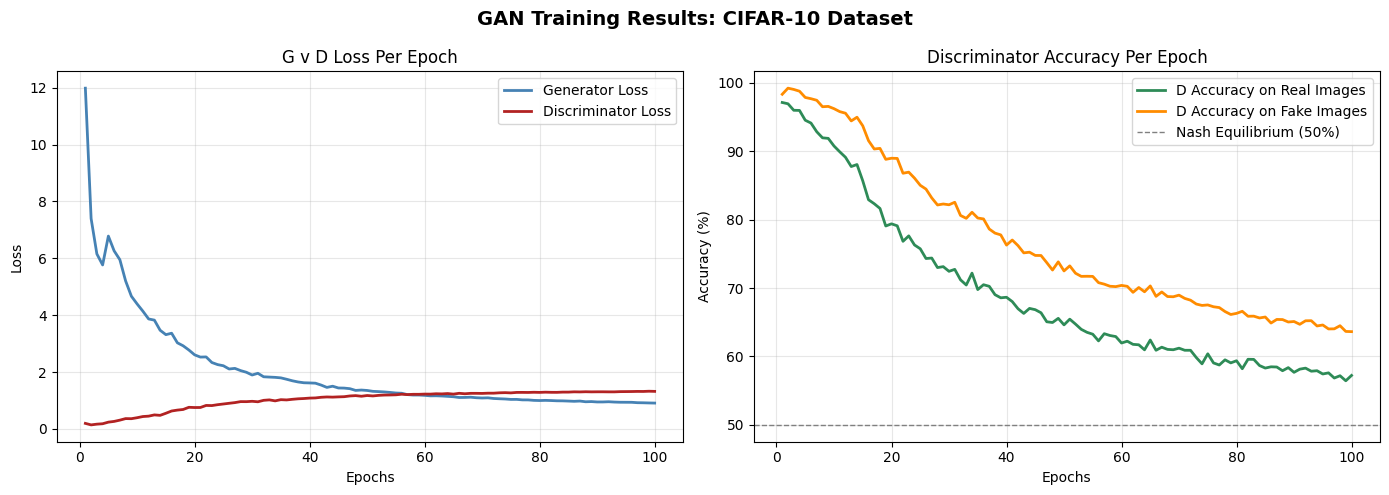

In [63]:
'''
This section will plot the training and validation loss curves for GAN 

usiing matplotlib
        loss_G     : list of avg Generator loss per epoch
        loss_D     : list of avg Discriminator loss per epoch
        D_acc_real : list of avg D accuracy on real images per epoch
        D_acc_fake : list of avg D accuracy on fake images per epoch
        num_epochs : total epochs trained

'''

# get epochs for x-axis
epochs = range(1, num_epochs + 1)

# ==== Plot losses ====
# get figure size 
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# sub title 
fig.suptitle("GAN Training Results: CIFAR-10 Dataset", fontsize=14, fontweight='bold')


# ----- Plotting: Loss  ----- 

axes[0].plot(epochs, G_loss,color='steelblue', markersize=6, linewidth=2, label=f'Generator Loss')
axes[0].plot(epochs, D_loss,color='firebrick', markersize=6, linewidth=2, label=f'Discriminator Loss')

# set labels, titles, legends 
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('G v D Loss Per Epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()


# ----- Plotting: Accuracy  ----- 


# set labels, titles, legends
axes[1].plot(epochs, D_acc_real, color='seagreen', markersize=6, linewidth=2, label=f'D Accuracy on Real Images')
axes[1].plot(epochs, D_acc_fake, color='darkorange', markersize=6, linewidth=2, label=f'D Accuracy on Fake Images')
axes[1].axhline(y=50, color='gray', linestyle='--', linewidth=1, label='Nash Equilibrium (50%)')  
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Discriminator Accuracy Per Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gan_training_results.png', dpi=150, bbox_inches='tight')
print("GAN training results image saved!")
plt.show()

GAN generated samples image saved!


Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=3072, bias=True)
    (7): Tanh()
  )
)

<Figure size 640x480 with 0 Axes>

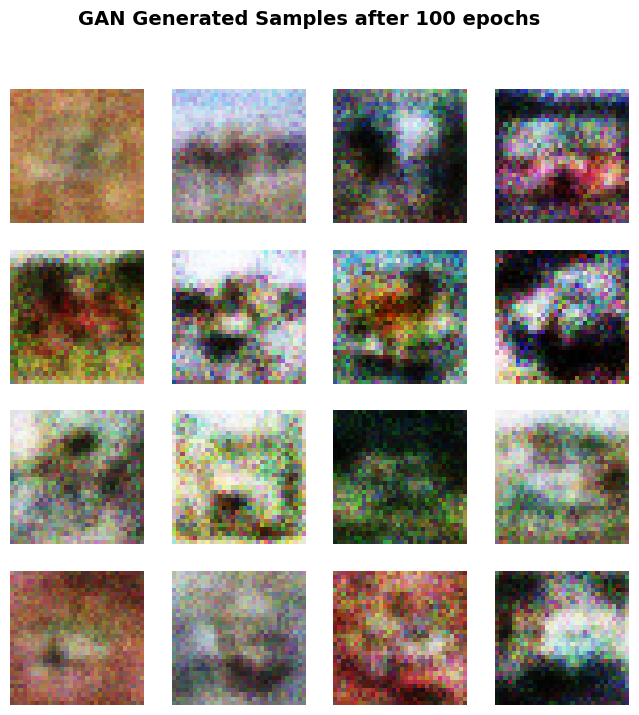

In [67]:
# ----- Generate Fake images generated by the trained Generator -----
'''
- Will use the fixed noise vectors from earlier; generates consistent images 
- We can verify if G is learning and produces from the same input 
- Expected:
    - 14 blurry outputs 
    - 2 outputs that look like real images (hopefully)
    - learned from Module 14 notes 
    - DCGAN and WGAN would produce sharper and structured images 
    
    - 4x4 grid of 16 generated images from the fixed noise vector 
    - G : Generator trained on CIFAR-10 dataset
    - fixed_noise: 16 random noise 
    - num_images: default 16 images 


'''

# set G top evaluation mode for inference
G.eval()

def generate_and_plot(G, fixed_noise, num_images=16):
    # Helper function to generate and plot images 
    
    # disable gradients for inference
    with torch.no_grad():
        # generate fake images from fixed noise on the correct device
        fake_images = G(fixed_noise).cpu()      # move to CPU for plotting, shape (16, 3, 32, 32) 16 images, 3 channels, 32x32 pixels
        
        # rescale images from [-1, 1] to [0, 1] 
        # https://pytorch.org/docs/stable/generated/torch.clamp.html - Clamp function to rescale pixels
        fake_images = (fake_images + 1) / 2    # rescale to [0, 1], takes the number from [-1, 1] and maps it to [0, 1]
        fake_images = torch.clamp(fake_images, 0, 1)  # ensure all values are in [0, 1]
        
        # plot 4x4 grid 
        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        fig.suptitle("GAN Generated Samples after 100 epochs", fontsize=14, fontweight='bold')
        
        # Iterate through the sample indices, get images, labels, predictions ---> display them
    for i, ax in enumerate(axes.flat):
        img = fake_images[i].permute(1, 2, 0)  # convert tensor to PIL image for plotting
        ax.imshow(img)
        ax.axis('off')  # hide axes for cleaner look
            
plt.tight_layout()
plt.savefig('gan_generated_samples.png', dpi=150, bbox_inches='tight')
print("GAN generated samples image saved!")


# ----- Run visulization of generated images -----
generate_and_plot(G, fixed_noise)

# turn off eval mode and back to train mode
G.train()

In [74]:
# ----- Evaluation on Results ----

'''
Analyzing the Nash Equilbrium and Loss Convergence

- Nash Equilibrium:
    - Occurs when D and G reach a point wher neither can improve thier performance without changing the other's strategy 
- Loss Convergence:
    - G Loss: should decrease and D should increase as G improves, tricking D 

'''
def check_nash_equilibrium(D_acc_real, D_acc_fake):
    # ---- Nash Equilibrium Analysis ----
    # get the arithmetic mean of D's accuracy in real and fake images then divide by 2 to get the average
    # then get the absolute difference between te average and 50%. LEts us see how close to the Nash Equilibrium 
    avg_D_acc = (D_acc_real[-1] + D_acc_fake[-1]) / 2
    nash_diff = abs(avg_D_acc - 50.0)

    print("=" * 50)
    print(f"Final D Accuracy on Real Images: {D_acc_real[-1]:.2f}%")
    print(f"Final D Accuracy on Fake Images: {D_acc_fake[-1]:.2f}%")
    print(f"Average final D Accuracy: {avg_D_acc:.2f}%")
    print(f"Deviation from Nash Equilibrium: {nash_diff:.2f}%")
    print("~" * 50)
    
    if nash_diff <= 60.0:
        print("Approaching Nash Equilibrium\n")
    else:
        print("Not close to Nash Equilibrium, potential issues with training dynamics")
        
def check_loss_convergence(G_loss, D_loss):
    g_improvement = ((G_loss[0] - G_loss[-1]) / G_loss[0]) * 100
    d_change = ((D_loss[0] - D_loss[-1]) / D_loss[0]) * 100
    
    print("=" * 50)
    print("Loss Convergence Analysis:")
    print(f"Initial G Loss to Final G Loss: {G_loss[0]:.2f} to {G_loss[-1]:.2f}")
    print(f"Improvement in G Loss: {g_improvement:.2f}%")
    print(f"Initial D Loss to Final D Loss: {D_loss[0]:.2f} to {D_loss[-1]:.2f}")
    print(f"Improvement in D Loss: {d_change:.2f}%")
    print("~" * 50)
    
    if G_loss[-1] > D_loss[-1]:
        print("G_loss is higher than D_loss, G has space to improve")
    else:
        print("G_loss is lower than D_loss, G is competing and D is risk of overfitting")
        
        
# ----- Run the evaluation of results -----
check_nash_equilibrium(D_acc_real, D_acc_fake)
check_loss_convergence(G_loss, D_loss)

Final D Accuracy on Real Images: 57.23%
Final D Accuracy on Fake Images: 63.63%
Average final D Accuracy: 60.43%
Deviation from Nash Equilibrium: 10.43%
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Approaching Nash Equilibrium

Loss Convergence Analysis:
Initial G Loss to Final G Loss: 11.99 to 0.91
Improvement in G Loss: 92.42%
Initial D Loss to Final D Loss: 0.19 to 1.32
Improvement in D Loss: -580.40%
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
G_loss is lower than D_loss, G is competing and D is risk of overfitting


#### Further Evaluation

**Training** Simple GAN trained on 100 epochs, CIFAR-10 dataset in 15mins and 25secs on CPU device

**Architecture** 
Redesigned to shift from a MINST design to a CIFAR-10 design. Dimensions had to be adjusted from 
(784 input, 28×28 reshape) --> (input 784 → 3072, reshape 28×28 → 32×32×3).

**Output** 
Generated 16 blurry images that show learned color distribution and spatial structure
- not random noise 
A full connected MLP GAN on CIFAR-10
- lacks colvolutional layers

**Limitations**
- G loss remains high than D at convergence
- G has room to improve
- 
